In [1]:
import sys
import os
import re
import json
import random
import string
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import shap
from transformers import pipeline
from tqdm.auto import tqdm
from datasets import load_dataset

from IPython.display import HTML, display
import html

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root containing the 'src' directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import load_prepared_splits
from src.utils import (
    build_ranking_specs,
    collect_token_indices_from_items,
    highlight_spans,
    make_json_serializable,
    mask_spans_in_text,
    predict_with_pipeline,
    probability_to_logit,
    rank_indices_by_score,
    save_aopc_outputs,
    select_top_fraction_indices,
    trim_char_span,
)

In [3]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Dataset and model
DATASET_NAME = "timonziegenbein/appropriateness-corpus"
MODEL_NAME = "timonziegenbein/appropriateness-classifier-binary"

# Columns
TEXT_COL = "post_text"
TEXT_NORM_COL = "text_norm"
LABEL_COL = "Inappropriateness"
ID_COL = "post_id"

# Class labels used by the Hugging Face classifier
APPROPRIATE_LABEL = "LABEL_0"
INAPPROPRIATE_LABEL = "LABEL_1"

# Inference settings
MAX_LENGTH = 512
BATCH_SIZE = 16
SHAP_BATCH_SIZE = 8

DEVICE = 0 if torch.cuda.is_available() else -1
TORCH_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# SHAP config search settings
QUANTILE_VALUES = [0.3, 0.4, 0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95]
WINDOW_SIZE_VALUES = [0, 1, 2, 3]

# Ablation settings
ABLATION_MODE = "mask"

# Output
BASE_DIR = PROJECT_ROOT / "results"
OUTPUT_DIR = BASE_DIR / "shap_results"
BASE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Pipeline device:", DEVICE)
print("Torch device:", TORCH_DEVICE)

Pipeline device: -1
Torch device: cpu


In [3]:
pipe = pipeline(
    "text-classification",
    model=MODEL_NAME,
    device=DEVICE,
    top_k=None,
    truncation=True,
    max_length=MAX_LENGTH
)

tokenizer = pipe.tokenizer
model = pipe.model
model.eval()

MASK_TOKEN = tokenizer.mask_token if tokenizer.mask_token is not None else "[MASK]"

print("Mask token:", MASK_TOKEN)
print("Model labels:", model.config.id2label)
pipe

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

Mask token: [MASK]
Model labels: {0: 'LABEL_0', 1: 'LABEL_1'}


TextClassificationPipeline: {'model': 'DebertaV2ForSequenceClassification', 'dtype': 'float32', 'device': 'cpu', 'input_modalities': 'text'}

# Load prepared data

In [4]:
df_all, train_df, val_df, test_df = load_prepared_splits()

print("All:", df_all.shape)
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)


print("Train confusion types:")
display(train_df["confusion_type"].value_counts())

print("Validation confusion types:")
display(val_df["confusion_type"].value_counts())

print("Test confusion types:")
display(test_df["confusion_type"].value_counts())

All: (2191, 30)
Train: (1533, 30)
Validation: (220, 30)
Test: (438, 30)
Train confusion types:


confusion_type
TP    785
TN    652
FN     48
FP     48
Name: count, dtype: int64

Validation confusion types:


confusion_type
TP    88
TN    66
FN    36
FP    30
Name: count, dtype: int64

Test confusion types:


confusion_type
TP    186
TN    142
FP     71
FN     39
Name: count, dtype: int64

# SHAP-based span localization

This notebook applies SHAP to the binary document-level appropriateness classifier and turns local attribution scores into candidate spans.

The workflow follows the Integrated Gradients notebook structure:

1. Predict labels for all splits with the Hugging Face pipeline.
2. Store stable `global_row_id` and confusion types.
3. Select validation true positives for configuration search.
4. Search quantile and window size jointly.
5. Evaluate configurations by masking all extracted spans and measuring `prob_drop`.
6. Select a final configuration based on validation plots.
7. Apply the selected configuration to train, validation, and test.

## Quantile and window size

For each argument, SHAP assigns one signed attribution value to each text segment for the target class `LABEL_1`.

Only positive SHAP values are used because the goal is to identify evidence that increases the inappropriate-class logit.

The quantile controls how selective the extraction is:
- lower quantile: more selected segments, higher coverage, more noise
- higher quantile: fewer selected segments, more selective but potentially lower recall

The window size expands each selected SHAP segment symmetrically:
- `window_size=0`: only selected SHAP segments
- `window_size=1`: one neighboring segment left and right
- `window_size=2`: two neighboring segments left and right

Overlapping or directly adjacent windows are merged into one span.

In [5]:
shap_model = shap.models.TransformersPipeline(
    pipe,
    rescale_to_logits=True
)

explainer_logits = shap.Explainer(shap_model)

In [6]:
def compute_segment_offsets(text, segments):
    """
    Compute approximate character offsets for SHAP text segments.
    
    SHAP text segments are expected to reconstruct the input text in sequence.
    The fallback search handles minor alignment issues.
    """
    offsets = []
    cursor = 0
    text = str(text)
    
    for segment in segments:
        segment = str(segment)
        expected_end = cursor + len(segment)
        
        if text[cursor:expected_end] == segment:
            start = cursor
            end = expected_end
        else:
            found = text.find(segment, cursor)
            if found >= 0:
                start = found
                end = found + len(segment)
            else:
                start = cursor
                end = min(len(text), expected_end)
        
        offsets.append((int(start), int(end)))
        cursor = end
    
    return offsets


def token_indices_for_char_span(token_offsets, valid_token_mask, char_start, char_end):
    """Return model token indices overlapping a character span."""
    token_indices = []
    
    for token_idx, ((tok_start, tok_end), is_valid) in enumerate(
        zip(token_offsets, valid_token_mask)
    ):
        if not is_valid:
            continue
        
        overlaps = tok_start < char_end and tok_end > char_start
        
        if overlaps:
            token_indices.append(int(token_idx))
    
    return token_indices


def compute_shap_data(text, max_length=MAX_LENGTH):
    """
    Compute SHAP values for one text and align SHAP segments to character and token spans.
    
    Returns:
    - SHAP text segments
    - signed SHAP scores for the inappropriate class
    - approximate character offsets
    - overlapping model token indices
    - metadata for span construction
    """
    text = str(text)
    
    shap_values = explainer_logits(
        [text],
        batch_size=SHAP_BATCH_SIZE
    )
    
    sv = shap_values[0, :, INAPPROPRIATE_LABEL]
    
    segments = [str(segment) for segment in list(sv.data)]
    shap_scores = np.array(sv.values, dtype=float)
    segment_offsets = compute_segment_offsets(text, segments)
    
    encoded = tokenizer(
        text,
        truncation=True,
        max_length=max_length,
        return_offsets_mapping=True,
        return_special_tokens_mask=True
    )
    
    input_ids = encoded["input_ids"]
    token_offsets = encoded["offset_mapping"]
    special_tokens_mask = encoded["special_tokens_mask"]
    tokens = tokenizer.convert_ids_to_tokens(input_ids)
    
    valid_token_mask = []
    
    for start, end, special_mask in zip(
        [x[0] for x in token_offsets],
        [x[1] for x in token_offsets],
        special_tokens_mask
    ):
        is_valid = (
            special_mask == 0
            and end > start
            and start >= 0
            and end <= len(text)
        )
        valid_token_mask.append(is_valid)
    
    segment_items = []
    
    for segment_idx, (segment, score, (char_start, char_end)) in enumerate(
        zip(segments, shap_scores, segment_offsets)
    ):
        token_indices = token_indices_for_char_span(
            token_offsets=token_offsets,
            valid_token_mask=valid_token_mask,
            char_start=char_start,
            char_end=char_end
        )
        
        segment_items.append({
            "segment_idx": int(segment_idx),
            "text": segment,
            "char_start": int(char_start),
            "char_end": int(char_end),
            "score": float(score),
            "positive_score": float(max(score, 0.0)),
            "abs_score": float(abs(score)),
            "token_indices": token_indices,
            "token_start_idx": int(min(token_indices)) if token_indices else None,
            "token_end_idx": int(max(token_indices)) if token_indices else None,
            "token_texts": [tokens[idx] for idx in token_indices],
            "n_tokens": int(len(token_indices))
        })
    
    n_model_tokens = int(np.array(valid_token_mask, dtype=bool).sum())
    
    return {
        "text": text,
        "segments": segment_items,
        "tokens": tokens,
        "token_offsets": token_offsets,
        "valid_token_mask": valid_token_mask,
        "raw_shap_values": shap_scores,
        "n_model_tokens": n_model_tokens,
        "n_segments": int(len(segment_items)),
        "was_truncated": bool(len(input_ids) >= max_length)
    }

## Fuctions for precomputing and caching SHAP data

In [8]:
def precompute_shap_cache(df, matrix_positions, cache_path=None, overwrite=False):
    """
    Precompute SHAP data once per argument.

    The cache is keyed by global_row_id and can be reused for AOPC and
    quantile/window-size config search.
    """
    if cache_path is not None:
        cache_path = Path(cache_path)

        if cache_path.exists() and not overwrite:
            print("Loading SHAP cache from:", cache_path)

            with open(cache_path, "r", encoding="utf-8") as f:
                cache_items = json.load(f)

            return {
                int(item["global_row_id"]): item["shap_data"]
                for item in cache_items
            }

    shap_cache = {}

    for matrix_pos in tqdm(matrix_positions, desc="Precomputing SHAP cache"):
        row = df.iloc[matrix_pos]
        global_row_id = int(row["global_row_id"])
        text = str(row[TEXT_NORM_COL])

        try:
            shap_data = compute_shap_data(
                text=text,
                max_length=MAX_LENGTH
            )

            shap_cache[global_row_id] = shap_data

        except Exception as e:
            shap_cache[global_row_id] = {
                "error": str(e),
                "text": text,
                "segments": [],
                "tokens": [],
                "token_offsets": [],
                "valid_token_mask": [],
                "raw_shap_values": [],
                "n_model_tokens": 0,
                "n_segments": 0,
                "was_truncated": False
            }

    if cache_path is not None:
        cache_path.parent.mkdir(parents=True, exist_ok=True)

        with open(cache_path, "w", encoding="utf-8") as f:
            json.dump(
                [
                    {
                        "global_row_id": int(global_row_id),
                        "shap_data": make_json_serializable(shap_data)
                    }
                    for global_row_id, shap_data in shap_cache.items()
                ],
                f,
                ensure_ascii=False
            )

        print("Saved SHAP cache to:", cache_path)

    return shap_cache


def get_shap_data_for_row(row, shap_cache=None):
    """
    Return cached SHAP data if available. Otherwise compute SHAP data directly.
    """
    global_row_id = int(row["global_row_id"])

    if shap_cache is not None and global_row_id in shap_cache:
        shap_data = shap_cache[global_row_id]

        if shap_data.get("error") is not None:
            raise RuntimeError(shap_data["error"])

        return shap_data

    text = str(row[TEXT_NORM_COL])

    return compute_shap_data(
        text=text,
        max_length=MAX_LENGTH
    )

In [9]:
# Example sanity check on one validation true positive, if available.
val_tp_preview = val_df[val_df["confusion_type"] == "TP"].head(1)

if len(val_tp_preview) > 0:
    example_text = val_tp_preview.iloc[0][TEXT_NORM_COL]
    shap_data_example = compute_shap_data(example_text)
    
    print("Segments:", shap_data_example["n_segments"])
    print("Model tokens:", shap_data_example["n_model_tokens"])
    print("Was truncated:", shap_data_example["was_truncated"])
    
    display(pd.DataFrame(shap_data_example["segments"]).head(20))
else:
    print("No validation true positive example found.")

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [02:50, 170.15s/it]              

Segments: 63
Model tokens: 61
Was truncated: False


,segment_idx,text,char_start,char_end,score,positive_score,abs_score,token_indices,token_start_idx,token_end_idx,token_texts,n_tokens
0,0,,0,0,0.073630,0.073630,0.073630,[],NaN,NaN,[],0
1,1,The,0,3,0.268312,0.268312,0.268312,[1],1.0,1.0,[▁The],1
2,2,only,3,8,0.130998,0.130998,0.130998,[2],2.0,2.0,[▁only],1
3,3,other,8,14,0.115308,0.115308,0.115308,[3],3.0,3.0,[▁other],1
4,4,choices,14,22,0.081825,0.081825,0.081825,[4],4.0,4.0,[▁choices],1
5,5,are,22,26,0.093810,0.093810,0.093810,[5],5.0,5.0,[▁are],1
6,6,",",26,27,0.078981,0.078981,0.078981,[6],6.0,6.0,"[,]",1
7,7,adoption,27,36,0.045747,0.045747,0.045747,[7],7.0,7.0,[▁adoption],1
8,8,or,36,39,0.157299,0.157299,0.157299,[8],8.0,8.0,[▁or],1
9,9,keep,39,44,0.355035,0.355035,0.355035,[9],9.0,9.0,[▁keep],1


In [10]:
def selected_segment_indices(shap_data, quantile):
    """
    Select segments whose positive SHAP score is above the given per-argument quantile.
    
    Only positive attributions are considered because the target is to identify
    evidence that increases the inappropriate logit.
    """
    segments = shap_data["segments"]
    
    if not segments:
        return []
    
    positive_scores = np.array(
        [segment["positive_score"] for segment in segments],
        dtype=float
    )
    
    positive_only = positive_scores[positive_scores > 0]
    
    if len(positive_only) == 0:
        return []
    
    threshold = np.quantile(positive_only, quantile)
    
    selected = [
        i for i, score in enumerate(positive_scores)
        if score >= threshold and score > 0
    ]
    
    return selected


def merge_intervals(intervals):
    """Merge overlapping or directly adjacent intervals."""
    if len(intervals) == 0:
        return []
    
    intervals = sorted(intervals, key=lambda x: x[0])
    merged = [intervals[0]]
    
    for start, end in intervals[1:]:
        last_start, last_end = merged[-1]
        
        if start <= last_end + 1:
            merged[-1] = (last_start, max(last_end, end))
        else:
            merged.append((start, end))
    
    return merged


def is_only_punctuation_or_whitespace(span_text):
    """Return True if a span contains only punctuation or whitespace."""
    span_text = str(span_text).strip()
    
    if span_text == "":
        return True
    
    return all(char in string.punctuation for char in span_text)


def build_spans_from_selected_segments(shap_data, selected_indices, window_size):
    """
    Build merged spans from selected SHAP segments.
    
    In this SHAP setup, window_size is symmetric context expansion:
    - window_size=0 keeps only selected segments.
    - window_size=1 adds one segment to the left and right.
    - window_size=2 adds two segments to the left and right.
    
    Overlapping or directly adjacent windows are merged.
    """
    text = shap_data["text"]
    segments = shap_data["segments"]
    
    if not selected_indices:
        return []
    
    n_segments = len(segments)
    intervals = []
    
    for idx in sorted(selected_indices):
        start = max(0, idx - window_size)
        end = min(n_segments - 1, idx + window_size)
        intervals.append((start, end))
    
    merged_intervals = merge_intervals(intervals)
    spans = []
    
    for segment_start_idx, segment_end_idx in merged_intervals:
        span_segments = segments[segment_start_idx:segment_end_idx + 1]
        selected_segments = [
            segments[idx]
            for idx in selected_indices
            if segment_start_idx <= idx <= segment_end_idx
        ]
        
        char_start = min(segment["char_start"] for segment in span_segments)
        char_end = max(segment["char_end"] for segment in span_segments)
        char_start, char_end = trim_char_span(text, char_start, char_end)
        
        if char_end <= char_start:
            continue
        
        span_text = text[char_start:char_end]
        
        if is_only_punctuation_or_whitespace(span_text):
            continue
        
        token_indices_in_span = sorted({
            token_idx
            for segment in span_segments
            for token_idx in segment["token_indices"]
        })
        
        selected_token_indices = sorted({
            token_idx
            for segment in selected_segments
            for token_idx in segment["token_indices"]
        })
        
        selected_scores = np.array(
            [segment["positive_score"] for segment in selected_segments],
            dtype=float
        )
        
        positive_window_scores = np.array(
            [
                segment["positive_score"]
                for segment in span_segments
                if segment["positive_score"] > 0
            ],
            dtype=float
        )
        
        if len(selected_scores) == 0:
            continue
        
        spans.append({
            "char_start": int(char_start),
            "char_end": int(char_end),
            "segment_start_idx": int(segment_start_idx),
            "segment_end_idx": int(segment_end_idx),
            "token_start_idx": int(min(token_indices_in_span)) if token_indices_in_span else None,
            "token_end_idx": int(max(token_indices_in_span)) if token_indices_in_span else None,
            "span_text": span_text,
            "span_len_chars": int(char_end - char_start),
            "span_len_segments": int(segment_end_idx - segment_start_idx + 1),
            "span_len_tokens": int(len(token_indices_in_span)),
            "selected_segment_indices": [int(idx) for idx in selected_indices if segment_start_idx <= idx <= segment_end_idx],
            "selected_segment_texts": [segment["text"] for segment in selected_segments],
            "selected_token_indices": selected_token_indices,
            "selected_token_texts": [
                shap_data["tokens"][idx]
                for idx in selected_token_indices
            ],
            "span_score_sum_shap": float(selected_scores.sum()),
            "span_score_mean_shap": float(selected_scores.mean()),
            "span_score_max_shap": float(selected_scores.max()),
            "window_positive_score_sum_shap": float(positive_window_scores.sum()) if len(positive_window_scores) > 0 else 0.0,
            "window_positive_score_mean_shap": float(positive_window_scores.mean()) if len(positive_window_scores) > 0 else 0.0
        })
    
    for span_idx, span in enumerate(spans):
        span["span_idx"] = int(span_idx)
    
    return spans

In [11]:
test_text = "You are a complete idiot and your argument makes no sense."

test_spans = [
    {
        "char_start": test_text.index("complete idiot"),
        "char_end": test_text.index("complete idiot") + len("complete idiot"),
        "span_text": "complete idiot",
        "span_len_tokens": 2
    },
    {
        "char_start": test_text.index("makes no sense"),
        "char_end": test_text.index("makes no sense") + len("makes no sense"),
        "span_text": "makes no sense",
        "span_len_tokens": 3
    }
]

print(mask_spans_in_text(
    text=test_text,
    spans=test_spans,
    mask_token=MASK_TOKEN
))

You are a [MASK] [MASK] and your argument [MASK] [MASK] [MASK].


In [ ]:
def run_shap_config_on_indices(
    df,
    matrix_positions,
    quantile_values,
    window_size_values,
    mask_token=MASK_TOKEN,
    shap_cache=None,
    prediction_cache=None
):
    """
    Run SHAP span extraction and perturbation scoring.
    
    matrix_positions are split-local positions into df.
    global_row_id is stored as the stable identifier for downstream comparison.
    """
    all_results = []
    masked_texts_to_score = []
    masked_lookup = []

    if prediction_cache is None:
        prediction_cache = {}
    
    for matrix_pos in tqdm(matrix_positions, desc="Building SHAP spans"):
        row = df.iloc[matrix_pos]
        
        text = str(row[TEXT_NORM_COL])
        label = int(row[LABEL_COL])
        
        try:
            shap_data = get_shap_data_for_row(
                row=row,
                shap_cache=shap_cache
            )
            
            n_model_tokens = int(shap_data["n_model_tokens"])
            n_segments = int(shap_data["n_segments"])
            
            for quantile in quantile_values:
                selected_segment_idxs = selected_segment_indices(
                    shap_data=shap_data,
                    quantile=quantile
                )
                
                selected_token_idxs = sorted({
                    token_idx
                    for segment_idx in selected_segment_idxs
                    for token_idx in shap_data["segments"][segment_idx]["token_indices"]
                })
                
                for window_size in window_size_values:
                    merged_spans = build_spans_from_selected_segments(
                        shap_data=shap_data,
                        selected_indices=selected_segment_idxs,
                        window_size=window_size
                    )
                    
                    masked_text = mask_spans_in_text(
                        text=text,
                        spans=merged_spans,
                        mask_token=mask_token
                    )
                    
                    total_masked_tokens = sum(
                        span["span_len_tokens"]
                        for span in merged_spans
                    )
                    total_masked_chars = sum(
                        span["span_len_chars"]
                        for span in merged_spans
                    )
                    
                    masked_token_ratio = (
                        total_masked_tokens / n_model_tokens
                        if n_model_tokens > 0
                        else 0.0
                    )
                    
                    selected_token_ratio = (
                        len(selected_token_idxs) / n_model_tokens
                        if n_model_tokens > 0
                        else 0.0
                    )
                    
                    selected_segment_ratio = (
                        len(selected_segment_idxs) / n_segments
                        if n_segments > 0
                        else 0.0
                    )
                    
                    result = {
                        "global_row_id": int(row["global_row_id"]),
                        "split": row["split"],
                        "post_id": row[ID_COL] if ID_COL in df.columns else None,
                        "issue": row["issue"] if "issue" in df.columns else None,
                        
                        "label": label,
                        "predicted_label": row["predicted_label"],
                        "predicted_score": float(row["predicted_score"]),
                        "confusion_type": row["confusion_type"],
                        "is_true_positive": bool(row["is_true_positive"]),
                        "is_false_negative": bool(row["is_false_negative"]),
                        "is_false_positive": bool(row["is_false_positive"]),
                        "is_true_negative": bool(row["is_true_negative"]),
                        
                        "attribution_method": "shap",
                        "quantile": float(quantile),
                        "window_size": int(window_size),
                        "ablation_mode": "mask",
                        
                        "text": text,
                        "masked_text": masked_text,
                        
                        "p_inappropriate_original": float(row["p_inappropriate_original"]),
                        "logit_inappropriate_original": probability_to_logit(row["p_inappropriate_original"]),
                        
                        "n_model_tokens": n_model_tokens,
                        "n_segments": n_segments,
                        "n_selected_tokens": int(len(selected_token_idxs)),
                        "n_selected_segments": int(len(selected_segment_idxs)),
                        "selected_token_ratio": float(selected_token_ratio),
                        "selected_segment_ratio": float(selected_segment_ratio),
                        
                        "n_merged_spans": int(len(merged_spans)),
                        "total_masked_tokens": int(total_masked_tokens),
                        "total_masked_chars": int(total_masked_chars),
                        "masked_token_ratio": float(masked_token_ratio),
                        
                        "selected_segment_indices": [int(idx) for idx in selected_segment_idxs],
                        "selected_segment_texts": [
                            shap_data["segments"][idx]["text"]
                            for idx in selected_segment_idxs
                        ],
                        "selected_token_indices": [int(idx) for idx in selected_token_idxs],
                        "selected_token_texts": [
                            shap_data["tokens"][idx]
                            for idx in selected_token_idxs
                        ],
                        
                        "merged_spans": merged_spans,
                        "was_truncated": bool(shap_data["was_truncated"]),
                        "error": None
                    }
                    
                    all_results.append(result)
                    
                    if masked_text in prediction_cache:
                        pred_row = prediction_cache[masked_text]
                        p_masked = float(pred_row["p_inappropriate_original"])
                        logit_masked = probability_to_logit(p_masked)
                    
                        result["p_inappropriate_masked"] = p_masked
                        result["logit_inappropriate_masked"] = logit_masked
                        result["predicted_label_masked"] = pred_row["predicted_label"]
                        result["prob_drop"] = float(result["p_inappropriate_original"] - p_masked)
                        result["logit_drop"] = float(result["logit_inappropriate_original"] - logit_masked)
                    else:
                        masked_lookup.append(len(all_results) - 1)
                        masked_texts_to_score.append(masked_text)
        
        except Exception as e:
            result = {
                "global_row_id": int(row["global_row_id"]),
                "split": row["split"],
                "post_id": row[ID_COL] if ID_COL in df.columns else None,
                "issue": row["issue"] if "issue" in df.columns else None,
                
                "label": label,
                "predicted_label": row["predicted_label"],
                "predicted_score": float(row["predicted_score"]),
                "confusion_type": row["confusion_type"],
                "is_true_positive": bool(row["is_true_positive"]),
                "is_false_negative": bool(row["is_false_negative"]),
                "is_false_positive": bool(row["is_false_positive"]),
                "is_true_negative": bool(row["is_true_negative"]),
                
                "attribution_method": "shap",
                "quantile": None,
                "window_size": None,
                "ablation_mode": "mask",
                
                "text": text,
                "masked_text": text,
                
                "p_inappropriate_original": float(row["p_inappropriate_original"]),
                "logit_inappropriate_original": probability_to_logit(row["p_inappropriate_original"]),
                "p_inappropriate_masked": np.nan,
                "logit_inappropriate_masked": np.nan,
                "predicted_label_masked": None,
                "prob_drop": np.nan,
                "logit_drop": np.nan,
                
                "n_model_tokens": 0,
                "n_segments": 0,
                "n_selected_tokens": 0,
                "n_selected_segments": 0,
                "selected_token_ratio": 0.0,
                "selected_segment_ratio": 0.0,
                "n_merged_spans": 0,
                "total_masked_tokens": 0,
                "total_masked_chars": 0,
                "masked_token_ratio": 0.0,
                
                "selected_segment_indices": [],
                "selected_segment_texts": [],
                "selected_token_indices": [],
                "selected_token_texts": [],
                "merged_spans": [],
                "was_truncated": False,
                "error": str(e)
            }
            all_results.append(result)
    
    if len(masked_texts_to_score) > 0:
        masked_predictions = predict_with_pipeline(
            masked_texts_to_score,
            classifier=pipe,
            batch_size=BATCH_SIZE
        )

        for masked_text, result_idx, (_, pred_row) in zip(
            masked_texts_to_score,
            masked_lookup,
            masked_predictions.iterrows()
        ):
            result = all_results[result_idx]
            p_masked = float(pred_row["p_inappropriate_original"])
            logit_masked = probability_to_logit(p_masked)

            pred_dict = {
                "p_inappropriate_original": p_masked,
                "predicted_label": pred_row["predicted_label"],
                "predicted_score": float(pred_row["predicted_score"])
            }
            prediction_cache[masked_text] = pred_dict

            result["p_inappropriate_masked"] = p_masked
            result["logit_inappropriate_masked"] = logit_masked
            result["predicted_label_masked"] = pred_row["predicted_label"]
            result["prob_drop"] = float(result["p_inappropriate_original"] - p_masked)
            result["logit_drop"] = float(result["logit_inappropriate_original"] - logit_masked)

    return all_results

In [13]:
def build_argument_level_df(argument_results):
    """Flatten argument-level SHAP results for CSV export."""
    rows = []
    
    for result in argument_results:
        merged_span_texts = [span["span_text"] for span in result["merged_spans"]]
        merged_span_token_starts = [span["token_start_idx"] for span in result["merged_spans"]]
        merged_span_token_ends = [span["token_end_idx"] for span in result["merged_spans"]]
        merged_span_char_starts = [span["char_start"] for span in result["merged_spans"]]
        merged_span_char_ends = [span["char_end"] for span in result["merged_spans"]]
        
        rows.append({
            "global_row_id": result["global_row_id"],
            "split": result["split"],
            "post_id": result["post_id"],
            "issue": result["issue"],
            
            "label": result["label"],
            "predicted_label": result["predicted_label"],
            "predicted_score": result["predicted_score"],
            "confusion_type": result["confusion_type"],
            "is_true_positive": result["is_true_positive"],
            "is_false_negative": result["is_false_negative"],
            "is_false_positive": result["is_false_positive"],
            "is_true_negative": result["is_true_negative"],
            
            "attribution_method": result["attribution_method"],
            "quantile": result["quantile"],
            "window_size": result["window_size"],
            "ablation_mode": result["ablation_mode"],
            
            "p_inappropriate_original": result["p_inappropriate_original"],
            "p_inappropriate_masked": result["p_inappropriate_masked"],
            "predicted_label_masked": result["predicted_label_masked"],
            "prob_drop": result["prob_drop"],
            "logit_inappropriate_original": result["logit_inappropriate_original"],
            "logit_inappropriate_masked": result["logit_inappropriate_masked"],
            "logit_drop": result["logit_drop"],
            
            "n_model_tokens": result["n_model_tokens"],
            "n_segments": result["n_segments"],
            "n_selected_tokens": result["n_selected_tokens"],
            "n_selected_segments": result["n_selected_segments"],
            "selected_token_ratio": result["selected_token_ratio"],
            "selected_segment_ratio": result["selected_segment_ratio"],
            
            "n_merged_spans": result["n_merged_spans"],
            "total_masked_tokens": result["total_masked_tokens"],
            "total_masked_chars": result["total_masked_chars"],
            "masked_token_ratio": result["masked_token_ratio"],
            
            "selected_segment_indices": result["selected_segment_indices"],
            "selected_segment_texts": result["selected_segment_texts"],
            "selected_token_indices": result["selected_token_indices"],
            "selected_token_texts": result["selected_token_texts"],
            
            "merged_span_texts": merged_span_texts,
            "merged_span_token_start_indices": merged_span_token_starts,
            "merged_span_token_end_indices": merged_span_token_ends,
            "merged_span_char_start_indices": merged_span_char_starts,
            "merged_span_char_end_indices": merged_span_char_ends,
            
            "selected_segments_json": json.dumps(result["selected_segment_texts"], ensure_ascii=False),
            "selected_tokens_json": json.dumps(result["selected_token_texts"], ensure_ascii=False),
            "merged_spans_json": json.dumps(result["merged_spans"], ensure_ascii=False),
            
            "was_truncated": result["was_truncated"],
            
            "text": result["text"],
            "masked_text": result["masked_text"],
            "error": result["error"]
        })
    
    return pd.DataFrame(rows)


def build_span_level_df(argument_results):
    """Flatten span-level SHAP results for CSV export."""
    span_rows = []
    
    for result in argument_results:
        for span in result["merged_spans"]:
            span_rows.append({
                "global_row_id": result["global_row_id"],
                "split": result["split"],
                "post_id": result["post_id"],
                "issue": result["issue"],
                
                "label": result["label"],
                "predicted_label": result["predicted_label"],
                "confusion_type": result["confusion_type"],
                "is_true_positive": result["is_true_positive"],
                "is_false_negative": result["is_false_negative"],
                "is_false_positive": result["is_false_positive"],
                "is_true_negative": result["is_true_negative"],
                
                "attribution_method": result["attribution_method"],
                "quantile": result["quantile"],
                "window_size": result["window_size"],
                "ablation_mode": result["ablation_mode"],
                
                "span_idx": span["span_idx"],
                "span_text": span["span_text"],
                "char_start": span["char_start"],
                "char_end": span["char_end"],
                "segment_start_idx": span["segment_start_idx"],
                "segment_end_idx": span["segment_end_idx"],
                "token_start_idx": span["token_start_idx"],
                "token_end_idx": span["token_end_idx"],
                "span_len_chars": span["span_len_chars"],
                "span_len_segments": span["span_len_segments"],
                "span_len_tokens": span["span_len_tokens"],
                
                "selected_segment_indices": span["selected_segment_indices"],
                "selected_segment_texts": span["selected_segment_texts"],
                "selected_token_indices": span["selected_token_indices"],
                "selected_token_texts": span["selected_token_texts"],
                "span_score_sum_shap": span["span_score_sum_shap"],
                "span_score_mean_shap": span["span_score_mean_shap"],
                "span_score_max_shap": span["span_score_max_shap"],
                "window_positive_score_sum_shap": span["window_positive_score_sum_shap"],
                "window_positive_score_mean_shap": span["window_positive_score_mean_shap"],
                
                "p_inappropriate_original": result["p_inappropriate_original"],
                "p_inappropriate_masked": result["p_inappropriate_masked"],
                "prob_drop": result["prob_drop"],
                "logit_drop": result["logit_drop"],
                
                "n_model_tokens": result["n_model_tokens"],
                "n_segments": result["n_segments"],
                "n_selected_tokens": result["n_selected_tokens"],
                "n_selected_segments": result["n_selected_segments"],
                "selected_token_ratio": result["selected_token_ratio"],
                "selected_segment_ratio": result["selected_segment_ratio"],
                "masked_token_ratio": result["masked_token_ratio"],
                
                "was_truncated": result["was_truncated"],
                
                "text": result["text"],
                "masked_text": result["masked_text"]
            })
    
    return pd.DataFrame(span_rows)

In [14]:
train_val_df = pd.concat(
    [train_df, val_df],
    ignore_index=True
)

train_tp_positions = train_df.index[
    train_df["confusion_type"] == "TP"
].tolist()

val_tp_positions = val_df.index[
    val_df["confusion_type"] == "TP"
].tolist()

train_val_tp_positions = train_val_df.index[
    train_val_df["confusion_type"] == "TP"
].tolist()

print("Training examples:", len(train_df))
print("Training true positives:", len(train_tp_positions))
print("Validation examples:", len(val_df))
print("Validation true positives:", len(val_tp_positions))
print("Train + validation examples:", len(train_val_df))
print("Train + validation true positives:", len(train_val_tp_positions))

dev_shap_cache_path = OUTPUT_DIR / "shap_cache" / "shap_cache_dev_train_val_tp.json"

dev_shap_cache = precompute_shap_cache(
    df=train_val_df,
    matrix_positions=train_val_tp_positions,
    cache_path=dev_shap_cache_path,
    overwrite=False
)

dev_prediction_cache = {}

Training examples: 1533
Training true positives: 785
Validation examples: 220
Validation true positives: 88
Train + validation examples: 1753
Train + validation true positives: 873
Loading SHAP cache from: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/shap_results/shap_cache/shap_cache_dev_train_val_tp.json


# AOPC

In [15]:
# AOPC evaluates raw ranking quality, not span configuration quality.
# Therefore, these are fixed perturbation budgets, not tuned hyperparameters.
AOPC_FRACTIONS = [0.01, 0.05, 0.10, 0.20, 0.50]

# Minimal merging only for directly adjacent selected SHAP segments.
# This is not a tuned window-size setting.
AOPC_WINDOW_SIZE = 0

# Random control runs.
AOPC_RANDOM_RUNS = 10
AOPC_RANDOM_SEED = SEED

aopc_output_dir = OUTPUT_DIR / "aopc_ranking_evaluation"
aopc_output_dir.mkdir(parents=True, exist_ok=True)

print("AOPC fractions:", AOPC_FRACTIONS)
print("AOPC window size:", AOPC_WINDOW_SIZE)
print("Random runs:", AOPC_RANDOM_RUNS)
print("Output:", aopc_output_dir)

AOPC fractions: [0.01, 0.05, 0.1, 0.2, 0.5]
AOPC window size: 0
Random runs: 10
Output: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/shap_results/aopc_ranking_evaluation


In [ ]:
def run_shap_aopc_on_indices(
    df,
    matrix_positions,
    fractions=AOPC_FRACTIONS,
    random_runs=AOPC_RANDOM_RUNS,
    random_seed=AOPC_RANDOM_SEED,
    mask_token=MASK_TOKEN,
    shap_cache=None,
    prediction_cache=None
):
    """
    Run AOPC ranking evaluation for SHAP.

    This evaluates raw SHAP ranking quality:
    - no quantile tuning
    - no window-size tuning
    - no span configuration selection

    For each example and each perturbation fraction, the top-ranked SHAP
    segments are masked and the probability drop for LABEL_1 is measured.
    """
    rng = np.random.default_rng(random_seed)

    all_rows = []
    masked_texts_to_score = []
    masked_lookup = []

    if prediction_cache is None:
        prediction_cache = {}

    for matrix_pos in tqdm(matrix_positions, desc="SHAP AOPC ranking evaluation"):
        row = df.iloc[matrix_pos]
        text = str(row[TEXT_NORM_COL])
        label = int(row[LABEL_COL])

        try:
            shap_data = get_shap_data_for_row(
                row=row,
                shap_cache=shap_cache
            )

            n_segments = int(shap_data["n_segments"])
            n_model_tokens = int(shap_data["n_model_tokens"])

            shap_scores = [
                segment["positive_score"]
                for segment in shap_data["segments"]
            ]

            shap_ranked_segment_indices = rank_indices_by_score(
                scores=shap_scores,
            )

            ranking_specs = build_ranking_specs(
                primary_name="shap",
                primary_ranked_indices=shap_ranked_segment_indices,
                candidate_indices=range(n_segments),
                random_runs=random_runs,
                rng=rng,
            )

            for ranking_method, random_run, ranked_segment_indices in ranking_specs:
                for fraction in fractions:
                    selected_segment_idxs = select_top_fraction_indices(
                        ranked_indices=ranked_segment_indices,
                        total_items=n_segments,
                        fraction=fraction,
                        min_k=1,
                    )

                    selected_segment_idxs_in_text_order = sorted(selected_segment_idxs)

                    selected_token_idxs = collect_token_indices_from_items(
                        items=shap_data["segments"],
                        selected_indices=selected_segment_idxs_in_text_order,
                    )

                    # window_size=0 only merges directly adjacent selected segments.
                    # This is needed for clean masking but is not a tuned span config.
                    merged_spans = build_spans_from_selected_segments(
                        shap_data=shap_data,
                        selected_indices=selected_segment_idxs_in_text_order,
                        window_size=AOPC_WINDOW_SIZE
                    )

                    masked_text = mask_spans_in_text(
                        text=text,
                        spans=merged_spans,
                        mask_token=mask_token
                    )

                    total_masked_tokens = sum(
                        span["span_len_tokens"]
                        for span in merged_spans
                    )

                    total_masked_chars = sum(
                        span["span_len_chars"]
                        for span in merged_spans
                    )

                    masked_token_ratio = (
                        total_masked_tokens / n_model_tokens
                        if n_model_tokens > 0
                        else 0.0
                    )

                    selected_segment_ratio = (
                        len(selected_segment_idxs) / n_segments
                        if n_segments > 0
                        else 0.0
                    )

                    selected_token_ratio = (
                        len(selected_token_idxs) / n_model_tokens
                        if n_model_tokens > 0
                        else 0.0
                    )

                    result = {
                        "global_row_id": int(row["global_row_id"]),
                        "split": row["split"],
                        "post_id": row[ID_COL] if ID_COL in df.columns else None,
                        "issue": row["issue"] if "issue" in df.columns else None,

                        "label": label,
                        "predicted_label": row["predicted_label"],
                        "predicted_score": float(row["predicted_score"]),
                        "confusion_type": row["confusion_type"],
                        "is_true_positive": bool(row["is_true_positive"]),
                        "is_false_negative": bool(row["is_false_negative"]),
                        "is_false_positive": bool(row["is_false_positive"]),
                        "is_true_negative": bool(row["is_true_negative"]),

                        "ranking_method": ranking_method,
                        "attribution_method": "shap",
                        "random_run": random_run,

                        "perturbation_fraction": float(fraction),
                        "top_k_segments": int(len(selected_segment_idxs)),
                        "window_size": int(AOPC_WINDOW_SIZE),
                        "ablation_mode": "mask",

                        "text": text,
                        "masked_text": masked_text,

                        "p_inappropriate_original": float(row["p_inappropriate_original"]),
                        "logit_inappropriate_original": probability_to_logit(row["p_inappropriate_original"]),

                        "n_segments": n_segments,
                        "n_model_tokens": n_model_tokens,
                        "n_selected_segments": int(len(selected_segment_idxs)),
                        "n_selected_tokens": int(len(selected_token_idxs)),
                        "selected_segment_ratio": float(selected_segment_ratio),
                        "selected_token_ratio": float(selected_token_ratio),

                        "n_merged_spans": int(len(merged_spans)),
                        "total_masked_tokens": int(total_masked_tokens),
                        "total_masked_chars": int(total_masked_chars),
                        "masked_token_ratio": float(masked_token_ratio),

                        "selected_segment_indices_by_rank": [int(idx) for idx in selected_segment_idxs],
                        "selected_segment_indices": [int(idx) for idx in selected_segment_idxs_in_text_order],
                        "selected_segment_texts": [
                            shap_data["segments"][idx]["text"]
                            for idx in selected_segment_idxs_in_text_order
                        ],
                        "selected_token_indices": [int(idx) for idx in selected_token_idxs],
                        "selected_token_texts": [
                            shap_data["tokens"][idx]
                            for idx in selected_token_idxs
                        ],
                        "merged_spans": merged_spans,

                        "was_truncated": bool(shap_data["was_truncated"]),
                        "error": None
                    }

                    all_rows.append(result)

                    if masked_text in prediction_cache:
                        pred_row = prediction_cache[masked_text]
                        p_masked = float(pred_row["p_inappropriate_original"])
                        logit_masked = probability_to_logit(p_masked)

                        result["p_inappropriate_masked"] = p_masked
                        result["logit_inappropriate_masked"] = logit_masked
                        result["predicted_label_masked"] = pred_row["predicted_label"]
                        result["prob_drop"] = float(result["p_inappropriate_original"] - p_masked)
                        result["logit_drop"] = float(result["logit_inappropriate_original"] - logit_masked)
                    else:
                        masked_lookup.append(len(all_rows) - 1)
                        masked_texts_to_score.append(masked_text)

        except Exception as e:
            all_rows.append({
                "global_row_id": int(row["global_row_id"]),
                "split": row["split"],
                "post_id": row[ID_COL] if ID_COL in df.columns else None,
                "issue": row["issue"] if "issue" in df.columns else None,
                "label": label,
                "predicted_label": row["predicted_label"],
                "predicted_score": float(row["predicted_score"]),
                "confusion_type": row["confusion_type"],
                "ranking_method": "shap",
                "attribution_method": "shap",
                "random_run": None,
                "perturbation_fraction": np.nan,
                "top_k_segments": 0,
                "window_size": int(AOPC_WINDOW_SIZE),
                "ablation_mode": "mask",
                "text": text,
                "masked_text": text,
                "p_inappropriate_original": float(row["p_inappropriate_original"]),
                "logit_inappropriate_original": probability_to_logit(row["p_inappropriate_original"]),
                "p_inappropriate_masked": np.nan,
                "logit_inappropriate_masked": np.nan,
                "predicted_label_masked": None,
                "prob_drop": np.nan,
                "logit_drop": np.nan,
                "n_segments": 0,
                "n_model_tokens": 0,
                "n_selected_segments": 0,
                "n_selected_tokens": 0,
                "selected_segment_ratio": 0.0,
                "selected_token_ratio": 0.0,
                "n_merged_spans": 0,
                "total_masked_tokens": 0,
                "total_masked_chars": 0,
                "masked_token_ratio": 0.0,
                "selected_segment_indices_by_rank": [],
                "selected_segment_indices": [],
                "selected_segment_texts": [],
                "selected_token_indices": [],
                "selected_token_texts": [],
                "merged_spans": [],
                "was_truncated": False,
                "error": str(e)
            })

    if len(masked_texts_to_score) > 0:
        masked_predictions = predict_with_pipeline(
            masked_texts_to_score,
            classifier=pipe,
            batch_size=BATCH_SIZE
        )

        for masked_text, result_idx, (_, pred_row) in zip(
            masked_texts_to_score,
            masked_lookup,
            masked_predictions.iterrows()
        ):
            result = all_rows[result_idx]
            p_masked = float(pred_row["p_inappropriate_original"])
            logit_masked = probability_to_logit(p_masked)

            pred_dict = {
                "p_inappropriate_original": p_masked,
                "predicted_label": pred_row["predicted_label"],
                "predicted_score": float(pred_row["predicted_score"])
            }
            prediction_cache[masked_text] = pred_dict

            result["p_inappropriate_masked"] = p_masked
            result["logit_inappropriate_masked"] = logit_masked
            result["predicted_label_masked"] = pred_row["predicted_label"]
            result["prob_drop"] = float(result["p_inappropriate_original"] - p_masked)
            result["logit_drop"] = float(result["logit_inappropriate_original"] - logit_masked)

    return pd.DataFrame(all_rows)

In [21]:
def summarize_shap_aopc_results(aopc_df):
    """
    Summarize SHAP AOPC results.

    Random runs are averaged per argument and perturbation fraction before
    computing global summaries.
    """
    valid_df = aopc_df[
        aopc_df["error"].isna()
    ].copy()

    # Average random runs per argument and perturbation fraction.
    step_df = (
        valid_df
        .groupby(
            [
                "ranking_method",
                "global_row_id",
                "split",
                "post_id",
                "perturbation_fraction"
            ],
            as_index=False
        )
        .agg(
            prob_drop=("prob_drop", "mean"),
            logit_drop=("logit_drop", "mean"),
            p_inappropriate_original=("p_inappropriate_original", "first"),
            p_inappropriate_masked=("p_inappropriate_masked", "mean"),
            masked_token_ratio=("masked_token_ratio", "mean"),
            selected_segment_ratio=("selected_segment_ratio", "mean"),
            selected_token_ratio=("selected_token_ratio", "mean"),
            top_k_segments=("top_k_segments", "mean"),
            total_masked_tokens=("total_masked_tokens", "mean"),
            n_merged_spans=("n_merged_spans", "mean"),
        )
    )

    curve_summary = (
        step_df
        .groupby(["ranking_method", "perturbation_fraction"], as_index=False)
        .agg(
            n_arguments=("global_row_id", "nunique"),
            mean_prob_drop=("prob_drop", "mean"),
            median_prob_drop=("prob_drop", "median"),
            std_prob_drop=("prob_drop", "std"),
            mean_logit_drop=("logit_drop", "mean"),
            median_logit_drop=("logit_drop", "median"),
            positive_drop_rate=("prob_drop", lambda x: float((x > 0).mean())),
            mean_p_original=("p_inappropriate_original", "mean"),
            mean_p_masked=("p_inappropriate_masked", "mean"),
            mean_masked_token_ratio=("masked_token_ratio", "mean"),
            median_masked_token_ratio=("masked_token_ratio", "median"),
            mean_selected_segment_ratio=("selected_segment_ratio", "mean"),
            mean_selected_token_ratio=("selected_token_ratio", "mean"),
            mean_top_k_segments=("top_k_segments", "mean"),
            mean_total_masked_tokens=("total_masked_tokens", "mean"),
            mean_n_merged_spans=("n_merged_spans", "mean"),
        )
    )

    per_argument_aopc = (
        step_df
        .groupby(["ranking_method", "global_row_id", "split", "post_id"], as_index=False)
        .agg(
            aopc_mean_prob_drop=("prob_drop", "mean"),
            aopc_median_prob_drop=("prob_drop", "median"),
            aopc_mean_logit_drop=("logit_drop", "mean"),
            max_prob_drop=("prob_drop", "max"),
            min_prob_drop=("prob_drop", "min"),
            positive_steps_rate=("prob_drop", lambda x: float((x > 0).mean())),
            mean_masked_token_ratio=("masked_token_ratio", "mean"),
            max_masked_token_ratio=("masked_token_ratio", "max"),
            mean_total_masked_tokens=("total_masked_tokens", "mean"),
        )
    )

    global_summary = (
        per_argument_aopc
        .groupby("ranking_method", as_index=False)
        .agg(
            n_arguments=("global_row_id", "nunique"),
            aopc_mean_prob_drop=("aopc_mean_prob_drop", "mean"),
            aopc_median_prob_drop=("aopc_mean_prob_drop", "median"),
            aopc_std_prob_drop=("aopc_mean_prob_drop", "std"),
            aopc_mean_logit_drop=("aopc_mean_logit_drop", "mean"),
            mean_positive_steps_rate=("positive_steps_rate", "mean"),
            mean_masked_token_ratio=("mean_masked_token_ratio", "mean"),
            mean_max_masked_token_ratio=("max_masked_token_ratio", "mean"),
            mean_total_masked_tokens=("mean_total_masked_tokens", "mean"),
        )
        .sort_values("ranking_method")
    )

    return step_df, curve_summary, per_argument_aopc, global_summary

In [ ]:
dev_aopc_df = run_shap_aopc_on_indices(
    df=train_val_df,
    matrix_positions=train_val_tp_positions,
    fractions=AOPC_FRACTIONS,
    random_runs=AOPC_RANDOM_RUNS,
    random_seed=AOPC_RANDOM_SEED,
    mask_token=MASK_TOKEN,
    shap_cache=dev_shap_cache,
    prediction_cache=dev_prediction_cache
)

dev_aopc_step_df, dev_aopc_curve_summary, dev_aopc_per_argument, dev_aopc_global_summary = summarize_shap_aopc_results(
    dev_aopc_df
)

display(dev_aopc_curve_summary)
display(dev_aopc_global_summary)

In [ ]:
dev_aopc_df_export = dev_aopc_df.copy()
dev_aopc_df_export["merged_spans_json"] = dev_aopc_df_export["merged_spans"].apply(
    lambda x: json.dumps(make_json_serializable(x), ensure_ascii=False)
)
dev_aopc_df_export = dev_aopc_df_export.drop(columns=["merged_spans"])

save_aopc_outputs(
    aopc_df=dev_aopc_df,
    raw_export_df=dev_aopc_df_export,
    step_df=dev_aopc_step_df,
    curve_summary=dev_aopc_curve_summary,
    per_argument_aopc=dev_aopc_per_argument,
    global_summary=dev_aopc_global_summary,
    output_dir=aopc_output_dir,
    prefix="shap_aopc_dev_train_val_tp",
)

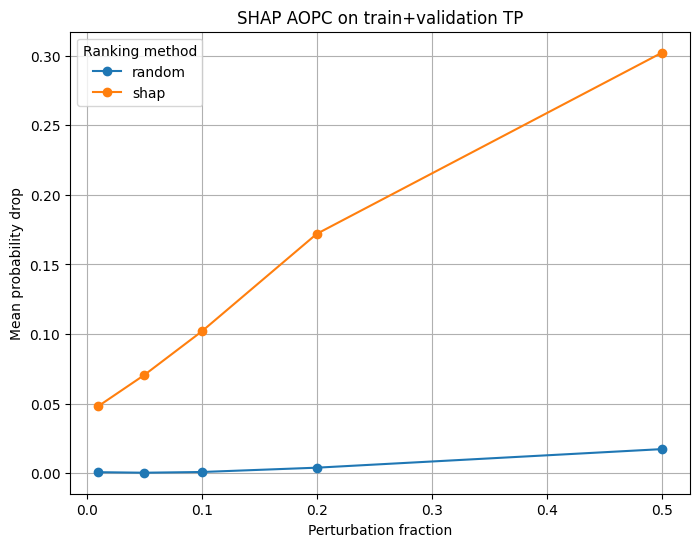

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/shap_results/aopc_ranking_evaluation/shap_aopc_dev_train_val_tp_curve.png


In [27]:
plot_df = dev_aopc_curve_summary.sort_values(
    ["ranking_method", "perturbation_fraction"]
).copy()

plt.figure(figsize=(8, 6))

for ranking_method in sorted(plot_df["ranking_method"].unique()):
    subset = plot_df[
        plot_df["ranking_method"] == ranking_method
    ]

    plt.plot(
        subset["perturbation_fraction"],
        subset["mean_prob_drop"],
        marker="o",
        label=ranking_method
    )

plt.xlabel("Perturbation fraction")
plt.ylabel("Mean probability drop")
plt.title("SHAP AOPC on train+validation TP")
plt.grid(True)
plt.legend(title="Ranking method")

plot_path = aopc_output_dir / "shap_aopc_dev_train_val_tp_curve.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

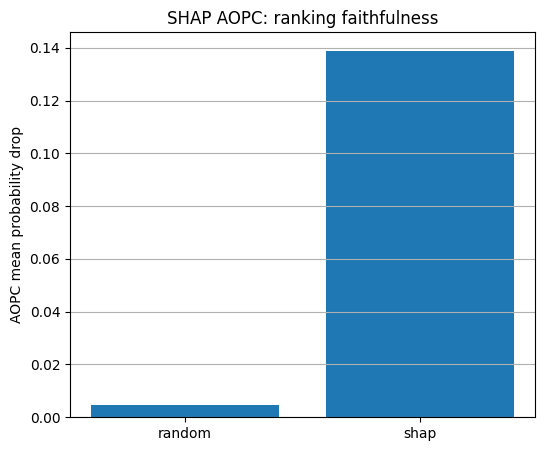

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/shap_results/aopc_ranking_evaluation/shap_aopc_dev_train_val_tp_global_bar.png


In [28]:
plot_df = dev_aopc_global_summary.sort_values("ranking_method").copy()

plt.figure(figsize=(6, 5))

plt.bar(
    plot_df["ranking_method"],
    plot_df["aopc_mean_prob_drop"]
)

plt.ylabel("AOPC mean probability drop")
plt.title("SHAP AOPC: ranking faithfulness")
plt.grid(axis="y")

plot_path = aopc_output_dir / "shap_aopc_dev_train_val_tp_global_bar.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

# Config Search

In [ ]:
train_val_tp_results = run_shap_config_on_indices(
    df=train_val_df,
    matrix_positions=train_val_tp_positions,
    quantile_values=QUANTILE_VALUES,
    window_size_values=WINDOW_SIZE_VALUES,
    mask_token=MASK_TOKEN,
    shap_cache=dev_shap_cache,
    prediction_cache=dev_prediction_cache
)

train_val_tp_argument_df = build_argument_level_df(train_val_tp_results)
train_val_tp_span_df = build_span_level_df(train_val_tp_results)

display(train_val_tp_argument_df.head())

,global_row_id,split,post_id,issue,label,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,...,merged_span_token_end_indices,merged_span_char_start_indices,merged_span_char_end_indices,selected_segments_json,selected_tokens_json,merged_spans_json,was_truncated,text,masked_text,error
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,"[7, 15, 26, 29, 33, 37]","[0, 45, 106, 127, 142, 157]","[29, 69, 118, 133, 151, 179]","[""people"", "" can"", ""t"", "" be"", "" forced"", "" to...","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 29, ""segment_st...",False,"people cant be forced to wear school uniforms,...",[MASK] school uniforms[MASK] theri own wish wh...,None
1,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,"[16, 38]","[0, 103]","[73, 184]","[""people"", "" can"", ""t"", "" be"", "" forced"", "" to...","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 73, ""segment_st...",False,"people cant be forced to wear school uniforms,...",[MASK]ri own wish whether they want [MASK] aga...,None
2,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,"[17, 39]","[0, 98]","[75, 190]","[""people"", "" can"", ""t"", "" be"", "" forced"", "" to...","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 75, ""segment_st...",False,"people cant be forced to wear school uniforms,...",[MASK] own wish whether they [MASK] regarding ...,None
3,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,"[18, 40]","[0, 93]","[79, 200]","[""people"", "" can"", ""t"", "" be"", "" forced"", "" to...","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 79, ""segment_st...",False,"people cant be forced to wear school uniforms,...",[MASK] wish whether [MASK] the uniforms,None
4,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,"[3, 5, 7, 15, 26, 29, 33, 37]","[0, 15, 25, 45, 106, 127, 142, 167]","[11, 21, 29, 69, 118, 133, 151, 179]","[""people"", "" can"", ""t"", "" forced"", "" wear"", "",...","[""▁people"", ""▁can"", ""t"", ""▁forced"", ""▁wear"", ""...","[{""char_start"": 0, ""char_end"": 11, ""segment_st...",False,"people cant be forced to wear school uniforms,...",[MASK] be [MASK] to [MASK] school uniforms[MAS...,None


,global_row_id,split,post_id,issue,label,predicted_label,confusion_type,is_true_positive,is_false_negative,is_false_positive,...,n_model_tokens,n_segments,n_selected_tokens,n_selected_segments,selected_token_ratio,selected_segment_ratio,masked_token_ratio,was_truncated,text,masked_text
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,42,44,23,23,0.547619,0.522727,0.547619,False,"people cant be forced to wear school uniforms,...",[MASK] school uniforms[MASK] theri own wish wh...
1,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,42,44,23,23,0.547619,0.522727,0.547619,False,"people cant be forced to wear school uniforms,...",[MASK] school uniforms[MASK] theri own wish wh...
2,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,42,44,23,23,0.547619,0.522727,0.547619,False,"people cant be forced to wear school uniforms,...",[MASK] school uniforms[MASK] theri own wish wh...
3,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,42,44,23,23,0.547619,0.522727,0.547619,False,"people cant be forced to wear school uniforms,...",[MASK] school uniforms[MASK] theri own wish wh...
4,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,42,44,23,23,0.547619,0.522727,0.547619,False,"people cant be forced to wear school uniforms,...",[MASK] school uniforms[MASK] theri own wish wh...


In [17]:
train_val_tp_argument_df_valid = train_val_tp_argument_df[
    train_val_tp_argument_df["error"].isna()
].copy()

train_val_config_summary = (
    train_val_tp_argument_df_valid
    .groupby(["attribution_method", "window_size", "quantile"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        mean_logit_drop=("logit_drop", "mean"),
        median_logit_drop=("logit_drop", "median"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_total_masked_chars=("total_masked_chars", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
        mean_n_selected_segments=("n_selected_segments", "mean"),
        mean_selected_segment_ratio=("selected_segment_ratio", "mean"),
        truncation_rate=("was_truncated", lambda x: x.mean()),
    )
    .reset_index()
)

train_val_config_summary = train_val_config_summary.sort_values(
    ["mean_prob_drop", "mean_masked_token_ratio"],
    ascending=[False, True]
).reset_index(drop=True)

display(train_val_config_summary)

,attribution_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,mean_logit_drop,median_logit_drop,positive_drop_rate,...,strong_drop_rate_005,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_total_masked_chars,mean_masked_token_ratio,mean_n_selected_segments,mean_selected_segment_ratio,truncation_rate
0,shap,3,0.30,873,0.310659,0.202094,0.325224,3.935382,3.990281,0.931271,...,0.570447,0.98933,0.678671,2.497136,72.985109,325.665521,0.846141,50.753723,0.553798,0.0
1,shap,3,0.40,873,0.294359,0.100061,0.336231,3.719011,3.315678,0.915235,...,0.532646,0.98933,0.694971,2.813288,68.762887,305.754868,0.809436,43.596793,0.476496,0.0
2,shap,2,0.30,873,0.289234,0.075216,0.339053,3.725020,3.468444,0.933562,...,0.526919,0.98933,0.700095,3.109966,68.735395,305.293242,0.805757,50.753723,0.553798,0.0
3,shap,2,0.40,873,0.275128,0.043761,0.346875,3.545190,2.846473,0.928981,...,0.489118,0.98933,0.714202,3.521191,63.690722,281.990836,0.758276,43.596793,0.476496,0.0
4,shap,3,0.50,873,0.267716,0.030407,0.340954,3.413019,2.520190,0.904926,...,0.474227,0.98933,0.721614,3.073310,63.641466,281.804124,0.761798,36.585338,0.401803,0.0
5,shap,3,0.60,873,0.247047,0.013543,0.348861,3.147158,1.906673,0.901489,...,0.422680,0.98933,0.742283,3.342497,57.316151,252.619702,0.695503,29.243986,0.321201,0.0
6,shap,1,0.30,873,0.235894,0.032298,0.329732,3.317414,2.616837,0.936999,...,0.461627,0.98933,0.753436,4.468499,61.964490,271.565865,0.732436,50.753723,0.553798,0.0
7,shap,2,0.50,873,0.235548,0.019306,0.338950,3.160100,2.141824,0.907216,...,0.430699,0.98933,0.753782,3.847652,57.876289,254.696449,0.699163,36.585338,0.401803,0.0
8,shap,0,0.30,873,0.232403,0.010679,0.368129,3.076087,1.720487,0.934708,...,0.355097,0.98933,0.756927,7.191294,49.545246,217.162658,0.561088,50.753723,0.553798,0.0
9,shap,0,0.40,873,0.231901,0.006879,0.371083,2.939191,1.416981,0.926690,...,0.337915,0.98933,0.757429,7.548683,42.344788,185.052692,0.480137,43.596793,0.476496,0.0


In [18]:
train_val_output_dir = OUTPUT_DIR / "config_selection"
train_val_output_dir.mkdir(parents=True, exist_ok=True)

train_val_tp_argument_df.to_csv(
    train_val_output_dir / "shap_train_val_tp_argument_level.csv",
    index=False,
    encoding="utf-8"
)

train_val_tp_span_df.to_csv(
    train_val_output_dir / "shap_train_val_tp_span_level.csv",
    index=False,
    encoding="utf-8"
)

train_val_config_summary.to_csv(
    train_val_output_dir / "shap_train_val_config_summary.csv",
    index=False,
    encoding="utf-8"
)

print("Saved config selection files to:", train_val_output_dir)

Saved config selection files to: shap_results_new/config_selection


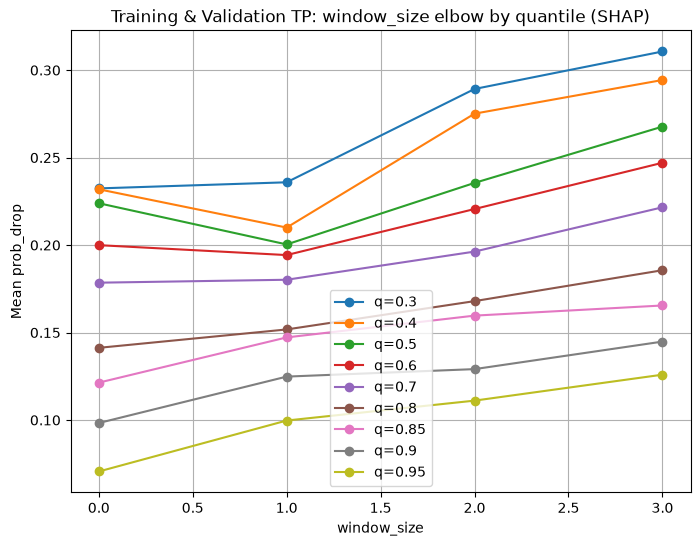

Saved plot: shap_results_new/config_selection/shap_train_val_window_elbow_by_quantile.png


In [19]:
method_df = train_val_config_summary[
    train_val_config_summary["attribution_method"] == "shap"
].copy()

plt.figure(figsize=(8, 6))

for quantile in sorted(method_df["quantile"].unique()):
    subset = method_df[
        method_df["quantile"] == quantile
    ].sort_values("window_size")
    
    plt.plot(
        subset["window_size"],
        subset["mean_prob_drop"],
        marker="o",
        label=f"q={quantile}"
    )

plt.xlabel("window_size")
plt.ylabel("Mean prob_drop")
plt.title("Training & Validation TP: window_size elbow by quantile (SHAP)")
plt.grid(True)
plt.legend()

plot_path = train_val_output_dir / "shap_train_val_window_elbow_by_quantile.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

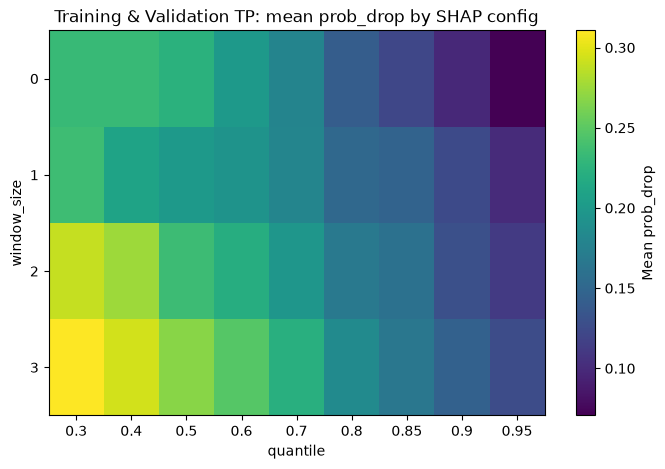

Saved plot: shap_results_new/config_selection/shap_train_val_find_config_heatmap.png


quantile,0.30,0.40,0.50,0.60,0.70,0.80,0.85,0.90,0.95
window_size,,,,,,,,,
0,0.232403,0.231901,0.223926,0.199962,0.178508,0.141267,0.121375,0.098298,0.070583
1,0.235894,0.210013,0.200376,0.194293,0.180186,0.151780,0.147230,0.124824,0.099713
2,0.289234,0.275128,0.235548,0.220622,0.196280,0.167970,0.159680,0.129104,0.111092
3,0.310659,0.294359,0.267716,0.247047,0.221597,0.185623,0.165477,0.144830,0.125920


In [20]:
method_df = train_val_config_summary[
    train_val_config_summary["attribution_method"] == "shap"
].copy()

heatmap_data = method_df.pivot(
    index="window_size",
    columns="quantile",
    values="mean_prob_drop"
)

plt.figure(figsize=(8, 5))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Mean prob_drop")

plt.xticks(
    ticks=np.arange(len(heatmap_data.columns)),
    labels=heatmap_data.columns
)
plt.yticks(
    ticks=np.arange(len(heatmap_data.index)),
    labels=heatmap_data.index
)

plt.xlabel("quantile")
plt.ylabel("window_size")
plt.title("Training & Validation TP: mean prob_drop by SHAP config")

plot_path = train_val_output_dir / "shap_train_val_find_config_heatmap.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)
display(heatmap_data)

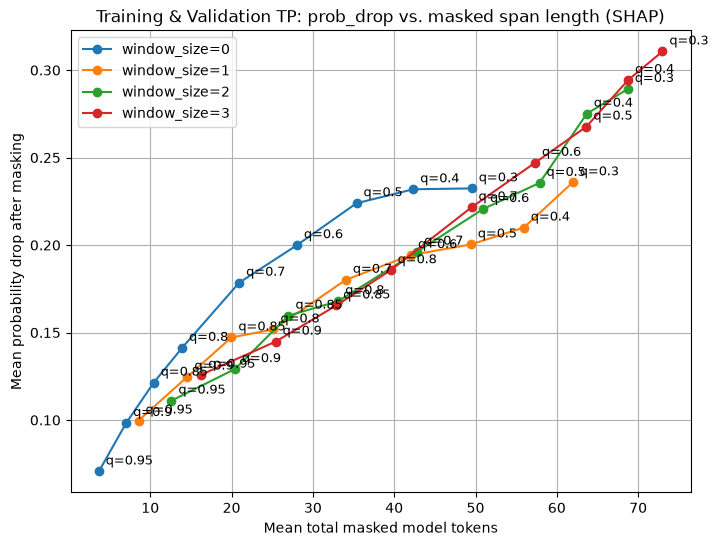

Saved plot: shap_results_new/config_selection/shap_train_val_prob_drop_vs_mean_masked_tokens.png


In [21]:
method_df = train_val_config_summary[
    train_val_config_summary["attribution_method"] == "shap"
].copy()

plt.figure(figsize=(8, 6))

for window_size in sorted(method_df["window_size"].unique()):
    subset = method_df[
        method_df["window_size"] == window_size
    ].sort_values("quantile")
    
    plt.plot(
        subset["mean_total_masked_tokens"],
        subset["mean_prob_drop"],
        marker="o",
        label=f"window_size={window_size}"
    )
    
    for _, row in subset.iterrows():
        plt.annotate(
            f"q={row['quantile']}",
            (row["mean_total_masked_tokens"], row["mean_prob_drop"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

plt.xlabel("Mean total masked model tokens")
plt.ylabel("Mean probability drop after masking")
plt.title("Training & Validation TP: prob_drop vs. masked span length (SHAP)")
plt.grid(True)
plt.legend()

plot_path = train_val_output_dir / "shap_train_val_prob_drop_vs_mean_masked_tokens.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

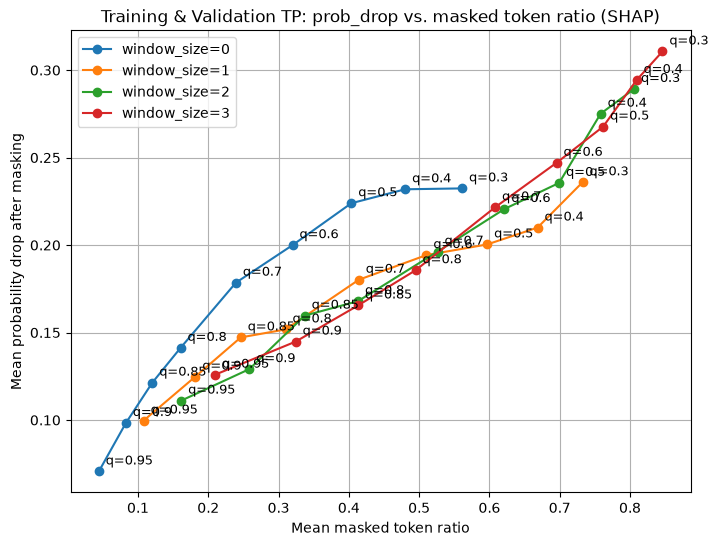

Saved plot: shap_results_new/config_selection/shap_train_val_prob_drop_vs_masked_token_ratio.png


In [22]:
method_df = train_val_config_summary[
    train_val_config_summary["attribution_method"] == "shap"
].copy()

plt.figure(figsize=(8, 6))

for window_size in sorted(method_df["window_size"].unique()):
    subset = method_df[
        method_df["window_size"] == window_size
    ].sort_values("quantile")
    
    plt.plot(
        subset["mean_masked_token_ratio"],
        subset["mean_prob_drop"],
        marker="o",
        label=f"window_size={window_size}"
    )
    
    for _, row in subset.iterrows():
        plt.annotate(
            f"q={row['quantile']}",
            (row["mean_masked_token_ratio"], row["mean_prob_drop"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

plt.xlabel("Mean masked token ratio")
plt.ylabel("Mean probability drop after masking")
plt.title("Training & Validation TP: prob_drop vs. masked token ratio (SHAP)")
plt.grid(True)
plt.legend()

plot_path = train_val_output_dir / "shap_train_val_prob_drop_vs_masked_token_ratio.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

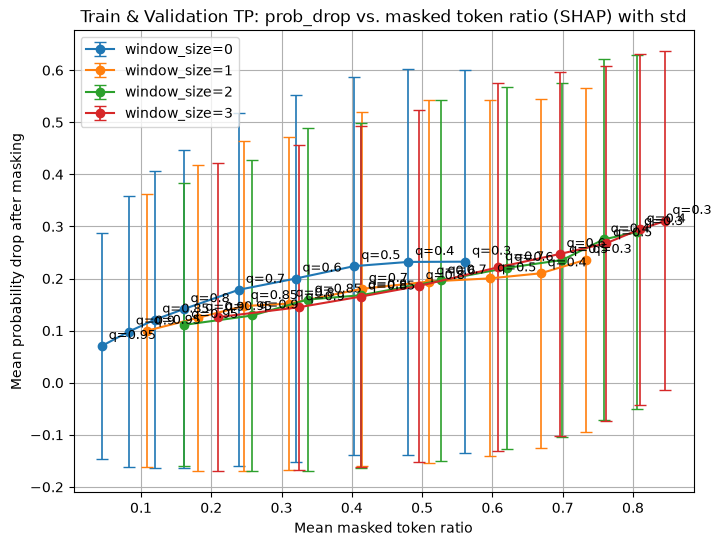

Saved plot: shap_results_new/config_selection/shap_train_val_prob_drop_vs_masked_token_ratio_std.png


In [23]:
method_df = train_val_config_summary[
    train_val_config_summary["attribution_method"] == "shap"
].copy()

plt.figure(figsize=(8, 6))

for window_size in sorted(method_df["window_size"].unique()):
    subset = method_df[
        method_df["window_size"] == window_size
    ].sort_values("quantile")
    
    plt.errorbar(
        subset["mean_masked_token_ratio"],
        subset["mean_prob_drop"],
        yerr=subset["std_prob_drop"],
        marker="o",
        linestyle="-",
        capsize=4,
        elinewidth=1.2,
        label=f"window_size={window_size}"
    )
    
    for _, row in subset.iterrows():
        plt.annotate(
            f"q={row['quantile']}",
            (row["mean_masked_token_ratio"], row["mean_prob_drop"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

plt.xlabel("Mean masked token ratio")
plt.ylabel("Mean probability drop after masking")
plt.title("Train & Validation TP: prob_drop vs. masked token ratio (SHAP) with std")
plt.grid(True)
plt.legend()

plot_path = train_val_output_dir / "shap_train_val_prob_drop_vs_masked_token_ratio_std.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

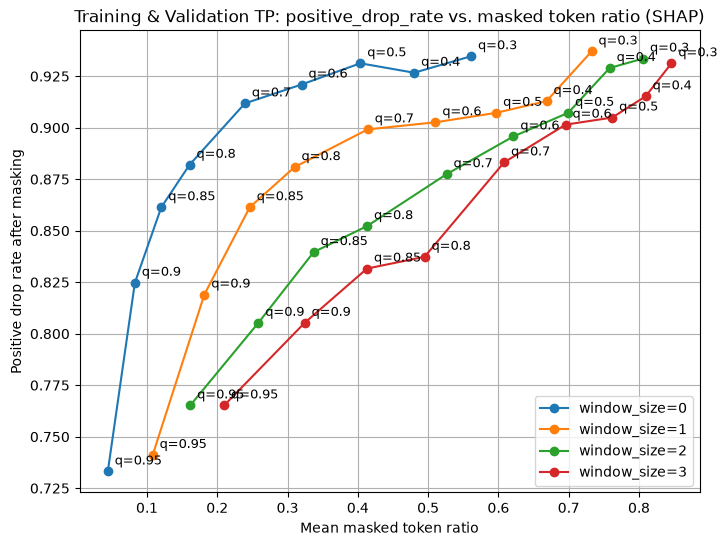

Saved plot: shap_results_new/config_selection/shap_train_val_positive_drop_rate_vs_masked_token_ratio.png


In [24]:
method_df = train_val_config_summary[
    train_val_config_summary["attribution_method"] == "shap"
].copy()

plt.figure(figsize=(8, 6))

for window_size in sorted(method_df["window_size"].unique()):
    subset = method_df[
        method_df["window_size"] == window_size
    ].sort_values("quantile")
    
    plt.plot(
        subset["mean_masked_token_ratio"],
        subset["positive_drop_rate"],
        marker="o",
        label=f"window_size={window_size}"
    )
    
    for _, row in subset.iterrows():
        plt.annotate(
            f"q={row['quantile']}",
            (row["mean_masked_token_ratio"], row["positive_drop_rate"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

plt.xlabel("Mean masked token ratio")
plt.ylabel("Positive drop rate after masking")
plt.title("Training & Validation TP: positive_drop_rate vs. masked token ratio (SHAP)")
plt.grid(True)
plt.legend()

plot_path = train_val_output_dir / "shap_train_val_positive_drop_rate_vs_masked_token_ratio.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

In [17]:
df = train_val_config_summary.copy()

# Hard localization constraint
df_eligible = df[
    df["mean_masked_token_ratio"] <= 0.65
].copy()

# Higher = better
df_eligible["rank_prob_drop"] = (
    df_eligible["mean_prob_drop"]
    .rank(pct=True, ascending=True)
)

df_eligible["rank_pdr"] = (
    df_eligible["positive_drop_rate"]
    .rank(pct=True, ascending=True)
)

# Lower MTR = better
df_eligible["rank_compactness"] = (
    df_eligible["mean_masked_token_ratio"]
    .rank(pct=True, ascending=False)
)

df_eligible["selection_score"] = (
    0.4 * df_eligible["rank_prob_drop"]
    + 0.4 * df_eligible["rank_pdr"]
    + 0.2 * df_eligible["rank_compactness"]
)

df_eligible = df_eligible.sort_values(
    "selection_score",
    ascending=False
)

df_eligible[
    [
        "quantile",
        "window_size",
        "mean_prob_drop",
        "positive_drop_rate",
        "mean_masked_token_ratio",
        "selection_score",
    ]
].head(10)

,quantile,window_size,mean_prob_drop,positive_drop_rate,mean_masked_token_ratio,selection_score
13,0.5,0,0.277939,0.971363,0.403519,0.750
10,0.4,0,0.308049,0.977090,0.480137,0.744
7,0.3,0,0.344843,0.980527,0.561088,0.724
16,0.6,0,0.229054,0.956472,0.319848,0.716
11,0.5,1,0.299746,0.969072,0.596796,0.642
20,0.7,0,0.170357,0.931271,0.239315,0.638
15,0.6,1,0.236618,0.959908,0.510368,0.636
18,0.7,1,0.198364,0.953036,0.414149,0.602
22,0.8,1,0.147757,0.926690,0.309962,0.560
17,0.7,2,0.228830,0.949599,0.526239,0.554


In [ ]:
# Final config selected from validation plots and summary.
# BEST_QUANTILE = 0.5
# BEST_WINDOW_SIZE = 0

BEST_QUANTILE = df_eligible['quantile'].iloc[0]
BEST_WINDOW_SIZE = df_eligible['window_size'].iloc[0]

train_val_config_summary = pd.read_csv("results/shap_results/config_selection/shap_train_val_config_summary.csv")

selected_config_summary = train_val_config_summary[
    (train_val_config_summary["attribution_method"] == "shap") &
    (train_val_config_summary["quantile"] == BEST_QUANTILE) &
    (train_val_config_summary["window_size"] == BEST_WINDOW_SIZE)
]

display(selected_config_summary)

,attribution_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,mean_logit_drop,median_logit_drop,positive_drop_rate,...,strong_drop_rate_005,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_total_masked_chars,mean_masked_token_ratio,mean_n_selected_segments,mean_selected_segment_ratio,truncation_rate
10,shap,0,0.5,873,0.223926,0.005388,0.363098,2.792263,1.232044,0.931271,...,0.332188,0.98933,0.765404,7.608247,35.366552,153.809851,0.403519,36.585338,0.401803,0.0


In [ ]:
def show_shap_example(result_df, index=0):
    """Display one SHAP result with highlighted masked spans."""
    row = result_df.iloc[index]
    
    spans = json.loads(row["merged_spans_json"])
    marked = highlight_spans(row["text"], spans)
    
    display(HTML(f"""
    <div style="
        border:1px solid #ccc;
        border-radius:8px;
        padding:14px;
        margin:12px 0;
        font-family:Arial, sans-serif;
        line-height:1.45;
    ">
        <b>global_row_id:</b> {html.escape(str(row["global_row_id"]))}<br>
        <b>post_id:</b> {html.escape(str(row["post_id"]))}<br>
        <b>split:</b> {html.escape(str(row["split"]))}<br>
        <b>confusion_type:</b> {html.escape(str(row["confusion_type"]))}<br>
        <b>issue:</b> {html.escape(str(row["issue"]))}<br>
        <b>method:</b> {html.escape(str(row["attribution_method"]))} |
        <b>quantile:</b> {row["quantile"]} |
        <b>window_size:</b> {row["window_size"]}<br>
        <b>merged_spans:</b> {html.escape(str(row["merged_span_texts"]))}<br>
        <b>p_original:</b> {float(row["p_inappropriate_original"]):.4f}<br>
        <b>p_masked:</b> {float(row["p_inappropriate_masked"]):.4f}<br>
        <b>prob_drop:</b> {float(row["prob_drop"]):.4f}<br>
        <b>logit_drop:</b> {float(row["logit_drop"]):.4f}<br>
        <b>masked_token_ratio:</b> {float(row["masked_token_ratio"]):.4f}<br>
        <hr>
        <p>{marked}</p>
    </div>
    """))

def show_builtin_shap_explanation(text, title=None):
    """
    Compute and display the built-in SHAP text visualization for one text.
    
    The visualization shows token/segment contributions to LABEL_1,
    where positive values support the inappropriate class and negative values
    work against it.
    """
    text = str(text)
    
    if title is not None:
        display(HTML(f"<h4>{html.escape(str(title))}</h4>"))
    
    shap_values = explainer_logits(
        [text],
        batch_size=SHAP_BATCH_SIZE
    )
    
    shap.plots.text(shap_values[0, :, INAPPROPRIATE_LABEL])
    
    return shap_values

In [32]:
train_val_best_examples = train_val_tp_argument_df[
    (train_val_tp_argument_df["attribution_method"] == "shap") &
    (train_val_tp_argument_df["quantile"] == BEST_QUANTILE) &
    (train_val_tp_argument_df["window_size"] == BEST_WINDOW_SIZE) &
    (train_val_tp_argument_df["error"].isna())
].copy()

print("Validation examples for selected SHAP config:", len(train_val_best_examples))

display(
    train_val_best_examples[
        [
            "global_row_id",
            "post_id",
            "prob_drop",
            "logit_drop",
            "masked_token_ratio",
            "merged_span_texts"
        ]
    ].head()
)

Validation examples for selected SHAP config: 873


,global_row_id,post_id,prob_drop,logit_drop,masked_token_ratio,merged_span_texts
8,0,1,0.068448,3.251851,0.404762,"[people cant, forced, wear, , i mean each pers..."
44,1,2,0.000196,0.104452,0.412500,"[That form of argument degrades this forum, wi..."
80,3,4,0.001052,0.595532,0.500000,"[No I wouldn't turn in my spouse., terrible pe..."
116,4,5,0.000188,0.111894,0.378378,[TV is terrible. Except for Spongebob maybe. T...
152,5,6,0.003161,1.037620,0.520000,"[I love, . They also improve your literature (..."


In [33]:
best_train_val_for_builtin = (
    train_val_best_examples
    .sort_values("prob_drop", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

for i, row in best_train_val_for_builtin.iterrows():
    title = (
        f"Validation example {i + 1} | "
        f"global_row_id={row['global_row_id']} | "
        f"post_id={row['post_id']} | "
        f"prob_drop={row['prob_drop']:.4f} | "
        f"logit_drop={row['logit_drop']:.4f}"
    )
    
    show_shap_example(best_train_val_for_builtin, index=i)
    show_builtin_shap_explanation(row["text"], title=title)

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:13, 13.83s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:13, 13.88s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:14, 14.40s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:14, 14.05s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:13, 13.65s/it]               


In [ ]:
test_tp_positions = test_df.index[
    test_df["confusion_type"] == "TP"
].tolist()

print("Test examples:", len(test_df))
print("Test true positives:", len(test_tp_positions))

test_aopc_df = run_shap_aopc_on_indices(
    df=test_df,
    matrix_positions=test_tp_positions,
    fractions=AOPC_FRACTIONS,
    random_runs=AOPC_RANDOM_RUNS,
    random_seed=AOPC_RANDOM_SEED,
    mask_token=MASK_TOKEN,
)

test_aopc_step_df, test_aopc_curve_summary, test_aopc_per_argument, test_aopc_global_summary = summarize_shap_aopc_results(
    test_aopc_df
)

display(test_aopc_curve_summary)
display(test_aopc_global_summary)

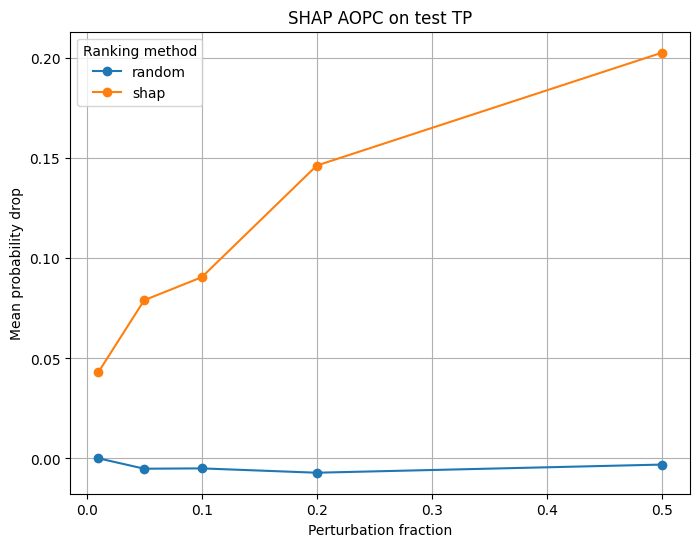

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/shap_results/aopc_ranking_evaluation/shap_aopc_test_tp_curve.png


In [30]:
plot_df = test_aopc_curve_summary.sort_values(
    ["ranking_method", "perturbation_fraction"]
).copy()

plt.figure(figsize=(8, 6))

for ranking_method in sorted(plot_df["ranking_method"].unique()):
    subset = plot_df[
        plot_df["ranking_method"] == ranking_method
    ]

    plt.plot(
        subset["perturbation_fraction"],
        subset["mean_prob_drop"],
        marker="o",
        label=ranking_method
    )

plt.xlabel("Perturbation fraction")
plt.ylabel("Mean probability drop")
plt.title("SHAP AOPC on test TP")
plt.grid(True)
plt.legend(title="Ranking method")

plot_path = aopc_output_dir / "shap_aopc_test_tp_curve.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

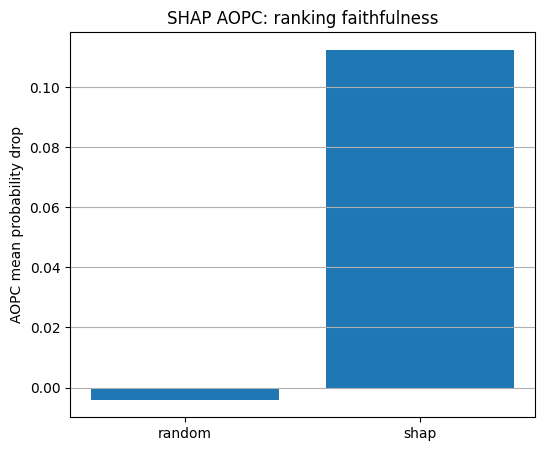

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/shap_results/aopc_ranking_evaluation/shap_aopc_test_tp_global_bar.png


In [31]:
plot_df = test_aopc_global_summary.sort_values("ranking_method").copy()

plt.figure(figsize=(6, 5))

plt.bar(
    plot_df["ranking_method"],
    plot_df["aopc_mean_prob_drop"]
)

plt.ylabel("AOPC mean probability drop")
plt.title("SHAP AOPC: ranking faithfulness")
plt.grid(axis="y")

plot_path = aopc_output_dir / "shap_aopc_test_tp_global_bar.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

## Final selected SHAP configuration

The final SHAP configuration is selected based on validation true positives.

The selected configuration is then applied to the test:

This produces comparable argument-level and span-level outputs for downstream comparison with Integrated Gradients, attention-based spans, and random baselines.

In [ ]:
test_shap_cache_path = OUTPUT_DIR / "shap_cache" / "shap_cache_test.json"

test_shap_cache = precompute_shap_cache(
    df=test_df,
    matrix_positions=list(range(len(test_df))),
    cache_path=test_shap_cache_path,
    overwrite=False
)

test_prediction_cache = {}

In [ ]:
def run_final_shap_on_split(df, split_name, shap_cache, prediction_cache):
    """
    Run the selected SHAP configuration on one split.
    
    The final configuration is fixed and not re-tuned per split.
    """
    positions = list(range(len(df)))
    
    results = run_shap_config_on_indices(
        df=df,
        matrix_positions=positions,
        quantile_values=[BEST_QUANTILE],
        window_size_values=[BEST_WINDOW_SIZE],
        mask_token=MASK_TOKEN,
        shap_cache=shap_cache,
        prediction_cache=prediction_cache
    )
    
    argument_df = build_argument_level_df(results)
    span_df = build_span_level_df(results)
    
    print(f"{split_name} argument level:", argument_df.shape)
    print(f"{split_name} span level:", span_df.shape)
    
    return results, argument_df, span_df


# train_results, train_argument_df, train_span_df = run_final_shap_on_split(
#    train_df,
#   "train"
# ) 

# val_results, val_argument_df, val_span_df = run_final_shap_on_split(
#     val_df,
#     "validation"
# )

test_results, test_argument_df, test_span_df = run_final_shap_on_split(
    test_df,
    "test",
    test_shap_cache,
    test_prediction_cache
)

In [19]:
# final_argument_df = pd.concat(
#     [train_argument_df, val_argument_df, test_argument_df],
#     ignore_index=True
# )

# final_span_df = pd.concat(
#     [train_span_df, val_span_df, test_span_df],
#     ignore_index=True
# )

final_argument_df = test_argument_df.copy()
final_span_df = test_span_df.copy()

display(final_argument_df.head())
display(final_span_df.head())

print("Final argument-level rows:", len(final_argument_df))
print("Final span-level rows:", len(final_span_df))

,global_row_id,split,post_id,issue,label,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,...,merged_span_token_end_indices,merged_span_char_start_indices,merged_span_char_end_indices,selected_segments_json,selected_tokens_json,merged_spans_json,was_truncated,text,masked_text,error
0,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,0.892726,FN,False,True,...,"[2, 7, 10]","[0, 36, 50]","[15, 39, 55]","[""students"", "" should"", "" and"", "" about""]","[""▁students"", ""▁should"", ""▁and"", ""▁about""]","[{""char_start"": 0, ""char_end"": 15, ""segment_st...",False,students should wear what they like and feel f...,[MASK] wear what they like [MASK] feel free [M...,None
1,1754,test,8,Tv is better than books:,1,LABEL_1,0.997475,TP,True,False,...,"[2, 8, 13, 18, 21, 27]","[0, 22, 46, 63, 78, 98]","[7, 36, 54, 71, 85, 112]","[""I"", "" thick"", "" better"", "" than"", "" TV"", "" b...","[""▁I"", ""▁thick"", ""▁better"", ""▁than"", ""▁TV"", ""▁...","[{""char_start"": 0, ""char_end"": 7, ""segment_sta...",False,I thick that book are better than TV is it is ...,[MASK] that book are [MASK] is it is [MASK] ca...,None
2,1755,test,9,Tv is better than books:,1,LABEL_1,0.998255,TP,True,False,...,"[6, 14, 16, 40, 71]","[0, 38, 70, 175, 284]","[31, 68, 75, 196, 335]","["""", ""Books"", "" enlighten"", "" the"", "" soul"", ""...","[""▁Books"", ""▁enlighten"", ""▁the"", ""▁soul"", ""."",...","[{""char_start"": 0, ""char_end"": 31, ""segment_st...",False,Books enlighten the soul. Books don't destroy ...,[MASK] don't [MASK]. [MASK] throw the mind int...,None
3,1756,test,12,India has the potential to lead the world:,1,LABEL_1,0.995627,TP,True,False,...,"[1, 4, 10, 13]","[0, 12, 31, 56]","[5, 16, 48, 65]","[""india"", "" good"", "" bad"", "" developer"", "" and...","[""▁india"", ""▁good"", ""▁bad"", ""▁developer"", ""▁an...","[{""char_start"": 0, ""char_end"": 5, ""segment_sta...",False,india is is good adopter but a bad developer a...,[MASK] is is [MASK] adopter but a [MASK] leade...,None
4,1757,test,15,Is it better to have a lousy father or to be f...,0,LABEL_0,0.993661,TN,False,False,...,"[13, 26, 52, 123]","[47, 101, 237, 544]","[57, 119, 248, 565]","["" not"", "" saying"", "" albeit"", "" a"", "" lousy"",...","[""▁not"", ""▁saying"", ""▁albeit"", ""▁a"", ""▁lousy"",...","[{""char_start"": 47, ""char_end"": 57, ""segment_s...",False,"Honestly, I'd rather be completely fatherless,...","Honestly, I'd rather be completely fatherless,...",None


,global_row_id,split,post_id,issue,label,predicted_label,confusion_type,is_true_positive,is_false_negative,is_false_positive,...,n_model_tokens,n_segments,n_selected_tokens,n_selected_segments,selected_token_ratio,selected_segment_ratio,masked_token_ratio,was_truncated,text,masked_text
0,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,FN,False,True,False,...,12,14,4,4,0.333333,0.285714,0.333333,False,students should wear what they like and feel f...,[MASK] wear what they like [MASK] feel free [M...
1,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,FN,False,True,False,...,12,14,4,4,0.333333,0.285714,0.333333,False,students should wear what they like and feel f...,[MASK] wear what they like [MASK] feel free [M...
2,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,FN,False,True,False,...,12,14,4,4,0.333333,0.285714,0.333333,False,students should wear what they like and feel f...,[MASK] wear what they like [MASK] feel free [M...
3,1754,test,8,Tv is better than books:,1,LABEL_1,TP,True,False,False,...,27,29,14,14,0.518519,0.482759,0.518519,False,I thick that book are better than TV is it is ...,[MASK] that book are [MASK] is it is [MASK] ca...
4,1754,test,8,Tv is better than books:,1,LABEL_1,TP,True,False,False,...,27,29,14,14,0.518519,0.482759,0.518519,False,I thick that book are better than TV is it is ...,[MASK] that book are [MASK] is it is [MASK] ca...


Final argument-level rows: 438
Final span-level rows: 2898


In [20]:
final_argument_df_valid = final_argument_df[
    final_argument_df["error"].isna()
].copy()

overall_summary = (
    final_argument_df_valid
    .groupby(["split", "attribution_method", "window_size", "quantile"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        mean_logit_drop=("logit_drop", "mean"),
        median_logit_drop=("logit_drop", "median"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
        truncation_rate=("was_truncated", lambda x: x.mean()),
    )
    .reset_index()
)

confusion_summary = (
    final_argument_df_valid
    .groupby(["split", "confusion_type"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        mean_logit_drop=("logit_drop", "mean"),
        median_logit_drop=("logit_drop", "median"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
    .sort_values(["split", "confusion_type"])
)

display(overall_summary)
display(confusion_summary)

,split,attribution_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,mean_logit_drop,median_logit_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio,truncation_rate
0,test,shap,0,0.5,438,0.122953,0.001854,0.333355,1.442079,0.518201,0.712329,0.347032,0.23516,0.590804,0.467851,6.616438,28.673516,0.317005,0.0


,split,confusion_type,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,mean_logit_drop,median_logit_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio
0,test,FN,39,-0.084955,0.000554,0.292414,-0.420882,0.086382,0.538462,0.049638,0.134594,4.564103,19.769231,0.186043
1,test,FP,71,0.395376,0.108663,0.432588,4.040494,3.147691,0.943662,0.971585,0.576209,6.746479,29.408451,0.358790
2,test,TN,142,-0.015718,-0.001267,0.129997,-0.206902,-0.202718,0.415493,0.037216,0.052934,5.690141,22.577465,0.204441
3,test,TP,186,0.168425,0.002186,0.326821,2.099731,0.758023,0.887097,0.981555,0.813130,7.704301,34.913978,0.414451


In [21]:
test_argument_df_valid = test_argument_df[
    test_argument_df["error"].isna()
].copy()

test_overall_summary = (
    test_argument_df_valid
    .groupby(["attribution_method", "window_size", "quantile"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        mean_logit_drop=("logit_drop", "mean"),
        median_logit_drop=("logit_drop", "median"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
        truncation_rate=("was_truncated", lambda x: x.mean()),
    )
    .reset_index()
)

test_confusion_summary = (
    test_argument_df_valid
    .groupby("confusion_type")
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        mean_logit_drop=("logit_drop", "mean"),
        median_logit_drop=("logit_drop", "median"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
    .sort_values("confusion_type")
)

display(test_overall_summary)
display(test_confusion_summary)

,attribution_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,mean_logit_drop,median_logit_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio,truncation_rate
0,shap,0,0.5,438,0.122953,0.001854,0.333355,1.442079,0.518201,0.712329,0.347032,0.23516,0.590804,0.467851,6.616438,28.673516,0.317005,0.0


,confusion_type,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,mean_logit_drop,median_logit_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio
0,FN,39,-0.084955,0.000554,0.292414,-0.420882,0.086382,0.538462,0.049638,0.134594,4.564103,19.769231,0.186043
1,FP,71,0.395376,0.108663,0.432588,4.040494,3.147691,0.943662,0.971585,0.576209,6.746479,29.408451,0.358790
2,TN,142,-0.015718,-0.001267,0.129997,-0.206902,-0.202718,0.415493,0.037216,0.052934,5.690141,22.577465,0.204441
3,TP,186,0.168425,0.002186,0.326821,2.099731,0.758023,0.887097,0.981555,0.813130,7.704301,34.913978,0.414451


In [23]:
final_output_dir = OUTPUT_DIR / "shap_results_final"
final_output_dir.mkdir(parents=True, exist_ok=True)

argument_csv_path = final_output_dir / (
    f"shap_final_test"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_argument_level.csv"
)

span_csv_path = final_output_dir / (
    f"shap_final_test"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_span_level.csv"
)

overall_summary_csv_path = final_output_dir / (
    f"shap_final_test"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_overall_summary.csv"
)

confusion_summary_csv_path = final_output_dir / (
    f"shap_final_test"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_confusion_summary.csv"
)

test_summary_csv_path = final_output_dir / (
    f"shap_final_test"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_summary.csv"
)

jsonl_path = final_output_dir / (
    f"shap_final_test"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_argument_level.jsonl"
)

final_argument_df.to_csv(argument_csv_path, index=False, encoding="utf-8")
final_span_df.to_csv(span_csv_path, index=False, encoding="utf-8")
overall_summary.to_csv(overall_summary_csv_path, index=False, encoding="utf-8")
confusion_summary.to_csv(confusion_summary_csv_path, index=False, encoding="utf-8")
test_overall_summary.to_csv(test_summary_csv_path, index=False, encoding="utf-8")

# all_results = train_results + val_results + test_results

with open(jsonl_path, "w", encoding="utf-8") as f:
    for result in test_results:
        safe_result = make_json_serializable(result)
        f.write(json.dumps(safe_result, ensure_ascii=False) + "\n")

print("Saved:")
print(argument_csv_path)
print(span_csv_path)
print(overall_summary_csv_path)
print(confusion_summary_csv_path)
print(test_summary_csv_path)
print(jsonl_path)

Saved:
shap_results_new/shap_results_final/shap_final_test_q0.5_window0_argument_level.csv
shap_results_new/shap_results_final/shap_final_test_q0.5_window0_span_level.csv
shap_results_new/shap_results_final/shap_final_test_q0.5_window0_overall_summary.csv
shap_results_new/shap_results_final/shap_final_test_q0.5_window0_confusion_summary.csv
shap_results_new/shap_results_final/shap_final_test_q0.5_window0_summary.csv
shap_results_new/shap_results_final/shap_final_test_q0.5_window0_argument_level.jsonl


In [24]:
# Best test examples by probability drop
tmp = (
    test_argument_df_valid
    .sort_values("prob_drop", ascending=False)
    .reset_index(drop=True)
)

for i in range(min(5, len(tmp))):
    show_shap_example(tmp, index=i)

In [25]:
# Test examples with the smallest or negative probability drops
tmp_low = (
    test_argument_df_valid
    .sort_values("prob_drop", ascending=True)
    .reset_index(drop=True)
)

for i in range(min(5, len(tmp_low))):
    show_shap_example(tmp_low, index=i)

In [26]:
best_test_for_builtin = (
    test_argument_df_valid
    .sort_values("prob_drop", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

for i, row in best_test_for_builtin.iterrows():
    title = (
        f"Test example {i + 1} | "
        f"global_row_id={row['global_row_id']} | "
        f"post_id={row['post_id']} | "
        f"prob_drop={row['prob_drop']:.4f} | "
        f"logit_drop={row['logit_drop']:.4f}"
    )
    
    show_shap_example(best_test_for_builtin, index=i)
    show_builtin_shap_explanation(row["text"], title=title)

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:13, 13.47s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:13, 13.60s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:13, 13.64s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:13, 13.57s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:13, 13.60s/it]               


In [27]:
weak_test_for_builtin = (
    test_argument_df_valid
    .sort_values("prob_drop", ascending=True)
    .head(5)
    .reset_index(drop=True)
)

for i, row in weak_test_for_builtin.iterrows():
    title = (
        f"Weak test example {i + 1} | "
        f"global_row_id={row['global_row_id']} | "
        f"post_id={row['post_id']} | "
        f"prob_drop={row['prob_drop']:.4f} | "
        f"logit_drop={row['logit_drop']:.4f}"
    )
    
    show_shap_example(weak_test_for_builtin, index=i)
    show_builtin_shap_explanation(row["text"], title=title)

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:13, 13.53s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:13, 13.61s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:13, 13.50s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:13, 13.44s/it]               
